# Lab 02 — Análisis (BTCUSDT 5m, Nivel B)

Este notebook **solo lee y muestra** resultados. Toda la lógica (estrategia, motor, regímenes,
walk-forward) vive en `src/` y se corre con `python main.py`, que guarda las tablas en `docs/tables/`
y las figuras en `docs/figures/`. Aquí no se define ninguna función ni se vuelve a correr nada.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import pandas as pd
from IPython.display import Image, display

TABLES = Path("docs/tables")
FIGURES = Path("docs/figures")
pd.set_option("display.width", 160)

## 1. Estrategia y regla 2 de 3

Los indicadores se calculan en **velas de 4 horas** (en 5 minutos el ATR, ~0.08%, es mucho más chico
que el costo de ida y vuelta de 0.25%) y se pasan a 5 minutos sin look-ahead: una vela de 4h solo se
usa cuando ya cerró. Cada indicador vota +1, −1 o 0:

- Tendencia: $\text{voto}_{ema} = \text{signo}(EMA_{rápida} - EMA_{lenta})$
- Momento: $\text{voto}_{roc} = \text{signo}(ROC_n)$
- Volatilidad: $\text{voto}_{bb} = +1$ si $\%B > u$; $-1$ si $\%B < 1-u$; 0 si no.

Con $L_t$ = número de votos +1 y $S_t$ = número de votos −1:

$$
\text{estado}_t = \begin{cases} +1 & L_t \ge 2 \ \text{y}\ ADX_t > \text{umbral} \\ -1 & S_t \ge 2 \ \text{y}\ ADX_t > \text{umbral} \\ 0 & \text{en otro caso} \end{cases}
\qquad
\text{señal}_t = \begin{cases} \text{estado}_t & \text{si } \text{estado}_t \ne \text{estado}_{t-1} \\ 0 & \text{si no} \end{cases}
$$

El ADX no vota: solo filtra la fuerza de la tendencia. **La señal se calcula en t y se ejecuta al
open de t+1.** Salidas: stop-loss a `sl_mult · ATR`, take-profit a `rr · stop`, holding máximo y
señal contraria. Tamaño: se arriesga `rho` del capital por operación, sin apalancamiento. Comisión
de 0.125% por lado. Detalle completo en `docs/SPEC.md`.

## 2. Walk-forward y resultados fuera de muestra (OOS) en train

73 ventanas: train de ~1 mes, test de la semana siguiente, avance de 7 días. En cada ventana hay
4 estudios de Optuna (global y uno por régimen), 100 trials cada uno, con objetivo Calmar del train.
En total se evaluaron **29,200 configuraciones**. Las 73 semanas de test forman una sola curva OOS
continua (2022-08-01 a 2023-12-25) con capital inicial de 1,000,000.

In [2]:
pd.read_csv(TABLES / "run_info.csv", index_col=0).round(1)

,value
windows,73.0
trials_per_study,100.0
configurations,29200.0
seconds,64.2
cpu_cores,10.0


In [3]:
pd.read_csv(TABLES / "metrics_oos.csv", index_col=0).round(3)

,con régimen,solo global,buy & hold
sharpe,-1.905,-0.482,1.312
sortino,-2.669,-0.728,1.872
calmar,-0.746,-0.334,1.497
max_drawdown,-0.349,-0.216,-0.379
win_rate,25.926,30.657,NaN
total_return,-0.337,-0.097,0.845
n_trades,162.000,137.000,0.000
exposure,0.639,0.614,1.000


**Fuera de muestra la estrategia pierde:** −33.7% con régimen y −9.7% solo global, mientras el
buy & hold gana +84.5% en el mismo periodo.

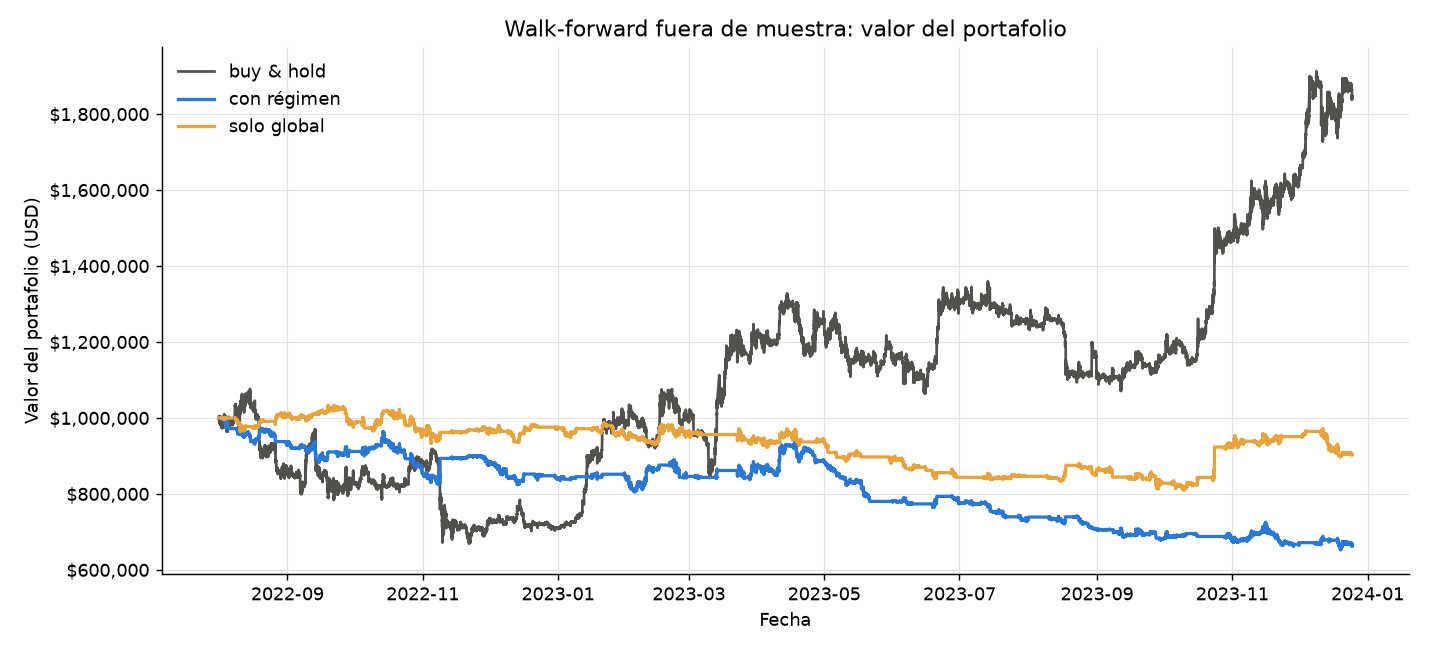

In [4]:
display(Image(filename=str(FIGURES / "portfolio_oos.png")))

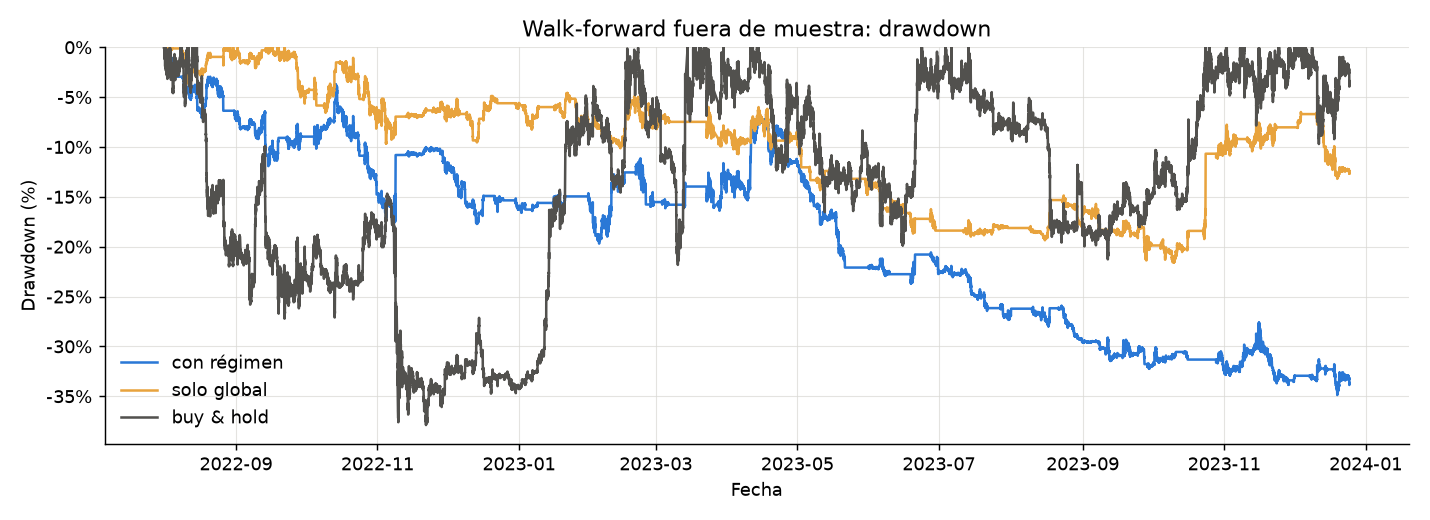

In [5]:
display(Image(filename=str(FIGURES / "drawdown_oos.png")))

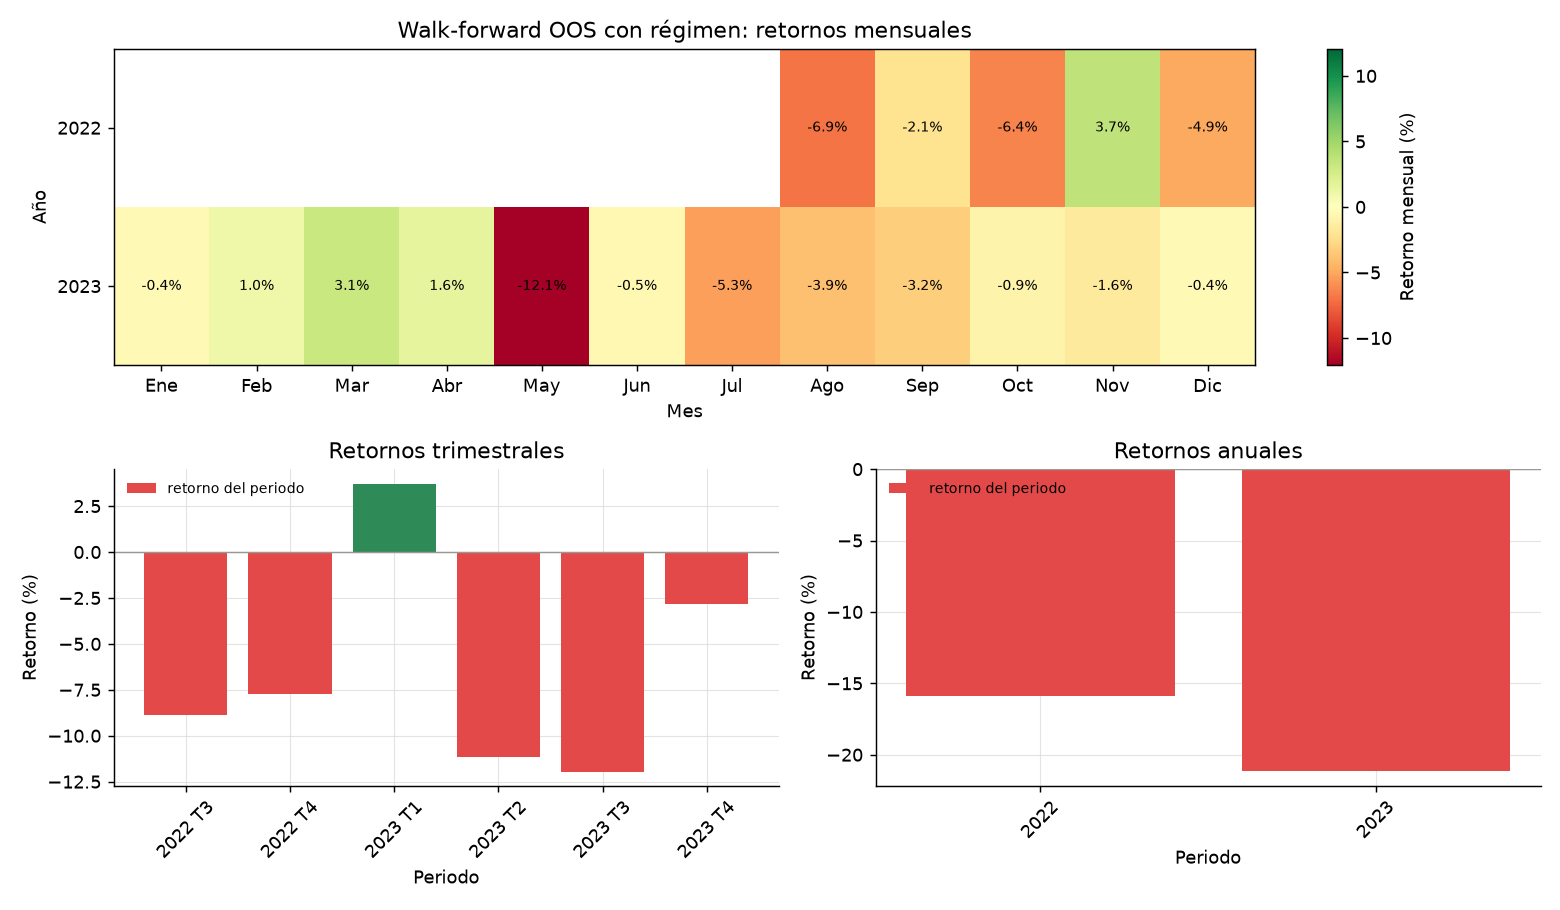

In [6]:
display(Image(filename=str(FIGURES / "returns_oos.png")))

## 3. Preguntas del PDF (sección 4)

### a) ¿La regla 2 de 3 mejora a un solo indicador?

Con θ_final global sobre todo el archivo de train:

In [7]:
pd.read_csv(TABLES / "single_vote.csv", index_col=0).round(3)

,n_trades,calmar
rule,,
EMA sola,78,-0.434
ROC sola,232,-0.082
BB sola,162,-0.228
2 de 3,170,-0.332


In [8]:
pd.read_csv(TABLES / "correlation_votes.csv", index_col=0).round(3)

,vote_ema,vote_roc,vote_bb
vote_ema,1.000,0.316,0.191
vote_roc,0.316,1.000,0.670
vote_bb,0.191,0.670,1.000


**No.** Las cuatro reglas pierden, y la 2 de 3 (170 trades, Calmar −0.33) queda **peor que ROC sola**
(232 trades, Calmar −0.08). La correlación explica parte: el voto de ROC y el de Bollinger se mueven
juntos (0.67), así que "2 de 3" casi siempre es "ROC y Bollinger de acuerdo"; el voto de EMA casi
nunca decide (en la sensibilidad, bajar ema_fast o slow_ratio 20% deja los 170 trades idénticos y
subirlos 20% mueve el Calmar menos de 0.01). Los tres votos
no son tan independientes como para confirmarse entre sí.

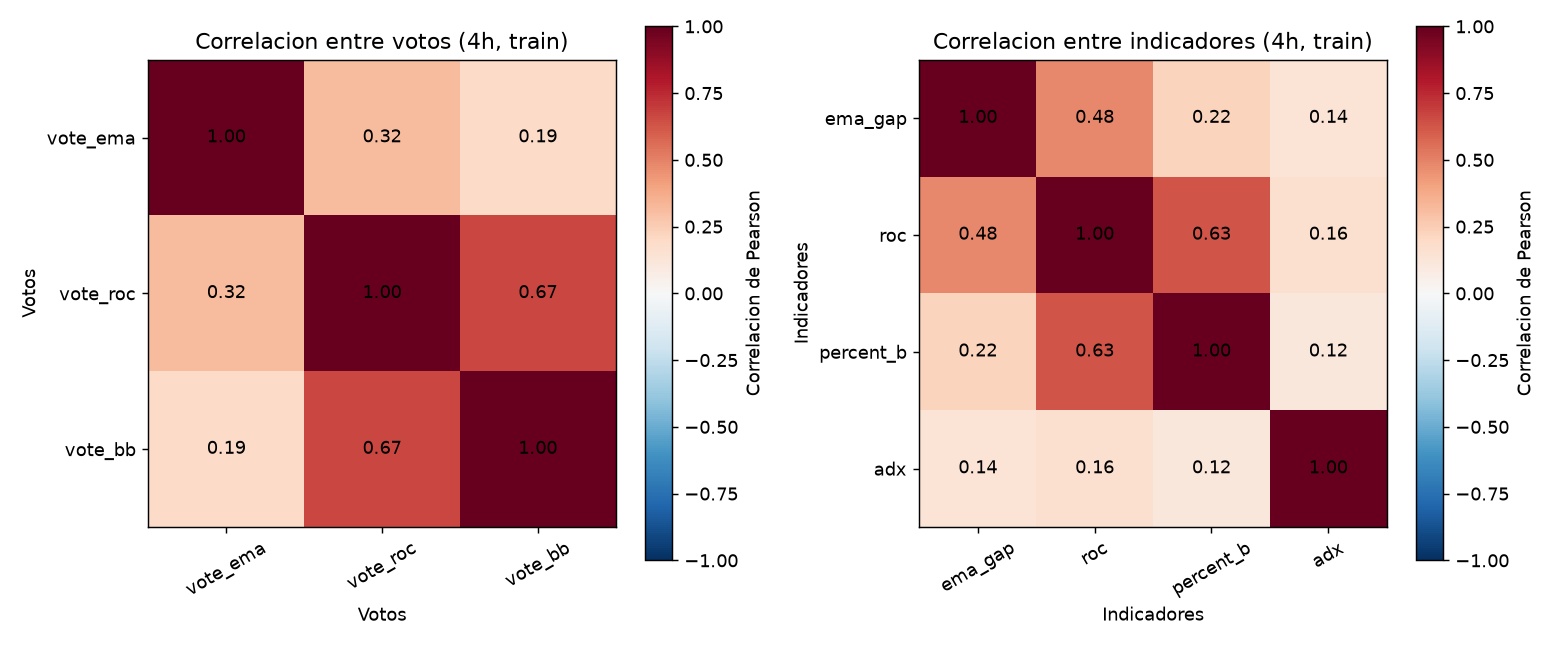

In [9]:
display(Image(filename=str(FIGURES / "correlation.png")))

### b) ¿Cuánto de la ventaja de train sobrevive fuera de muestra?

In [10]:
pd.read_csv(TABLES / "degradation_summary.csv").round(4)

,curve,comparison,train,oos,share_survives
0,con_regimen,calmar,54.3950,-0.7455,-0.0137
1,con_regimen,weekly_return,0.0176,-0.0053,-0.3046
2,solo_global,calmar,54.3950,-0.3344,-0.0061
3,solo_global,weekly_return,0.0176,-0.0012,-0.0677


**Nada.** En la misma escala (retorno por semana), el mejor trial gana en promedio +1.76% por semana
en su mes de train, y fuera de muestra la curva pierde −0.53% por semana con régimen y −0.12% solo
global: la proporción que sobrevive es negativa (−30% y −7%). El Calmar de train (mediana 54.4) no se
compara directo con el OOS: se anualiza desde ~4 semanas y su drawdown es el de un solo mes.
Es la señal clásica de **sobreajuste** a cada mes de train.

### c) Sensibilidad ±20%: ¿meseta o pico?

In [11]:
pd.read_csv(TABLES / "sensitivity.csv", index_col=0).round(3)

,value_minus_20,value_base,value_plus_20,calmar_minus_20,calmar_base,calmar_plus_20,at_limit_minus_20,at_limit_plus_20
param,,,,,,,,
ema_fast,16.000,20.000,24.000,-0.332,-0.332,-0.325,False,False
slow_ratio,3.492,4.365,5.237,-0.332,-0.332,-0.337,False,False
roc_window,15.000,19.000,23.000,0.141,-0.332,-0.253,False,False
bb_window,16.000,20.000,24.000,-0.329,-0.332,0.031,False,False
bb_threshold,0.560,0.700,0.839,-0.397,-0.332,0.277,False,False
adx_threshold,15.735,19.669,23.603,-0.236,-0.332,0.471,False,False
sl_mult,2.066,2.582,3.099,-0.442,-0.332,-0.035,False,False
rr,3.768,4.710,5.652,-0.440,-0.332,-0.154,False,False
max_holding,1325.000,1656.000,1987.000,-0.384,-0.332,-0.331,False,False


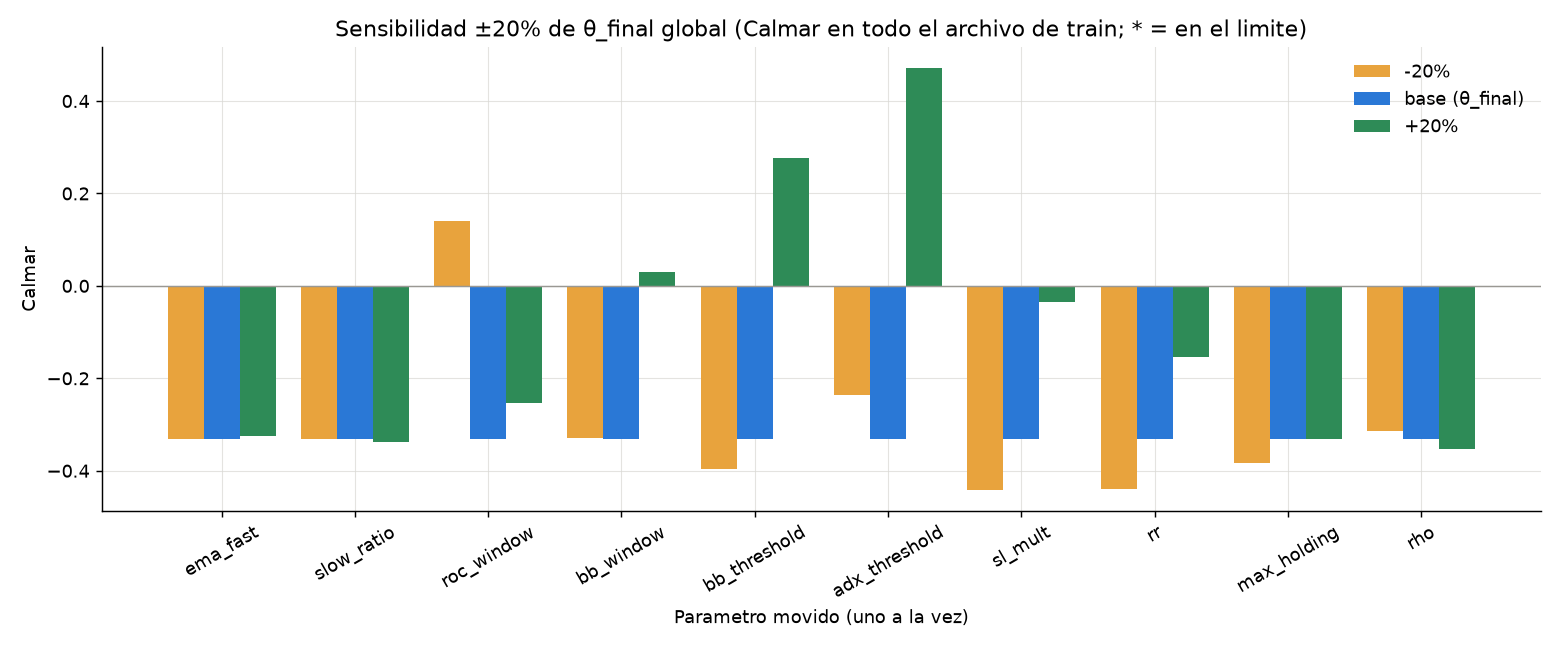

In [12]:
display(Image(filename=str(FIGURES / "sensitivity.png")))

**Pico, no meseta.** Mover un solo parámetro 20% cambia el signo del resultado: con `adx_threshold`
+20% el Calmar pasa de −0.33 a +0.47, con `bb_threshold` +20% a +0.28 y con `roc_window` −20% a
+0.14; con `sl_mult` o `rr` −20% empeora a −0.44. En una meseta el Calmar cambiaría poco. Que θ_final
(la mediana de las 73 ventanas) caiga en una zona mala, y que cerca haya valores mejores, es otra
señal de que los parámetros no son estables. Ningún valor quedó en el límite del espacio de búsqueda.

### d) Break-even de costos y margen contra 0.125%

In [13]:
pd.read_csv(TABLES / "cost_summary.csv", index_col=0).round(4)

,con_regimen,solo_global
gross_return_0bps,-0.16414439168558037,0.08669345398725148
return_at_real_cost,-0.33671861458635677,-0.09714344694641586
break_even_bps,NaN,5.6175651132425095
margin_bps,NaN,-6.8824348867574905
loses_without_costs,True,False


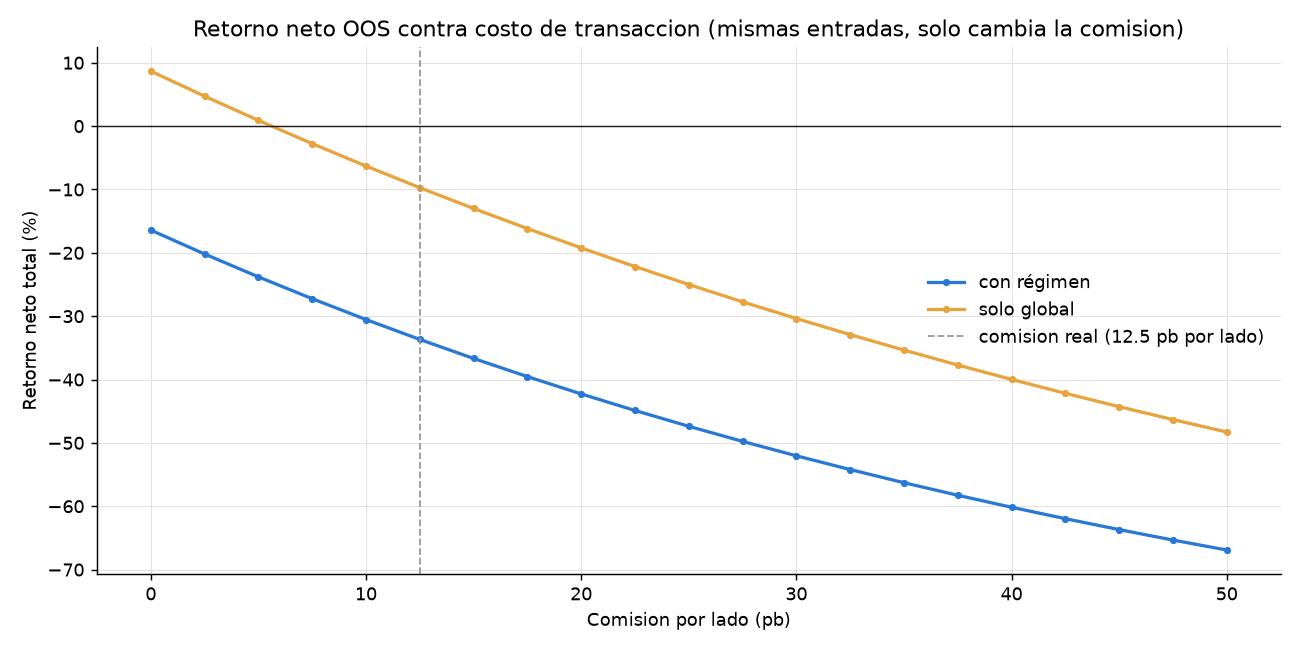

In [14]:
display(Image(filename=str(FIGURES / "cost_curve.png")))

Mismas entradas por barra de la curva OOS; solo cambia la comisión.
- **Con régimen pierde incluso sin comisión:** −16.4% con costo 0, así que no tiene break-even.
- **Solo global** gana +8.7% antes de costos y su **break-even es 5.6 pb por lado**. La comisión real
  es 12.5 pb: el margen es **−6.9 pb**. Para ser rentable necesitaría costos de menos de la mitad
  de los reales.

### e) ¿El desempeño difiere entre regímenes? ¿Qué aporta la capa de régimen?

Trades OOS de la curva con régimen, agrupados por el régimen de la barra de entrada (retorno por trade
sobre el nocional; IC bootstrap del 95% con 10,000 remuestreos y semilla 42):

In [15]:
pd.read_csv(TABLES / "regime_trades.csv", index_col=0).round(4)

,n_trades,win_rate,mean_return,ci_low,ci_high
regime,,,,,
crisis,6,50.0000,0.0038,-0.0110,0.0227
mean_reversion,98,20.4082,-0.0079,-0.0133,-0.0016
trend,58,32.7586,-0.0010,-0.0066,0.0050


In [16]:
pd.read_csv(TABLES / "kruskal.csv", index_col=0).round(4)

,value
h,10.3505
p_value,0.0057
groups,3.0000


**Sí difiere:** Kruskal-Wallis da H = 10.35 y **p = 0.006**. La estrategia, que es de tendencia,
pierde en reversión a la media: −0.79% por trade con IC [−1.33%, −0.16%], el único IC totalmente
negativo. En tendencia el promedio es −0.10% con un IC que cruza 0, y en crisis solo hay 6 trades.

**La capa de régimen no ayuda, empeora:** −33.7% con régimen contra −9.7% solo global. La salida por
crisis (R3) solo cerró 1 trade y en crisis casi siempre se usaron los parámetros globales (R5 en 59 de
73 ventanas), así que la diferencia viene de los parámetros optimizados por régimen, sobre todo los
de reversión a la media: más ajuste a la muestra, con menos trades por estudio.

### f) Tres limitaciones para operar con capital real

1. **Costos.** La comisión real (12.5 pb por lado) es más del doble del break-even (5.6 pb), y el
   impacto de mercado estimado suma ~2 pb más por lado.
2. **Parámetros inestables.** La sensibilidad muestra un pico, no una meseta, y la ventaja de train
   no sobrevive fuera de muestra: no sabemos qué θ usar mañana.
3. **Ejecución idealizada.** El backtest supone llenado completo al open, sin latencia, slippage 0 y
   sin costo de financiamiento de los cortos (funding de perpetuos o préstamo).

### g) Advertencia de ejecución e impacto de mercado

Estimación con el archivo de train y un modelo de raíz cuadrada:
impacto ≈ σ_5min · sqrt(nocional / volumen_5min).

In [17]:
pd.read_csv(TABLES / "market_impact.csv", index_col=0).round(4)

,avg_notional_usd,median_volume_5min_usd,median_volume_4h_usd,participation_5min_pct,participation_4h_pct,sigma_5min,impact_bps,break_even_bps,impact_vs_break_even_pct,bars_without_volume_pct
curve,,,,,,,,,,
con_regimen,468069.6460,21180416.0,699237376.0,2.2099,0.0669,0.0014,2.0158,5.6176,35.8838,46.0773
solo_global,497852.3479,21180416.0,699237376.0,2.3505,0.0712,0.0014,2.0789,5.6176,37.0078,46.0773


El nocional promedio por trade es de ~$470k–500k: el **2.2–2.4% del volumen mediano de una barra de
5 min** ($21.2M) y el 0.07% de una vela de 4h. El impacto estimado es de **~2 pb por lado**, más de un
tercio del break-even (5.6 pb). Es solo un orden de magnitud: el volumen de Yahoo es agregado (no de un
exchange) y falta en el 46% de las barras. Ejecutar al open de la barra siguiente, como supone el
backtest, no garantiza ese precio con órdenes de este tamaño.

## 4. Régimen de mercado (Nivel B)

Tres variables en ventana de 1 semana (volatilidad, trend_r2 y autocorrelación de 1 barra), régimen
actualizado cada hora. Se eligió el método de **reglas**; K-means y HMM son solo para comparar.

In [18]:
pd.read_csv(TABLES / "regime_validation.csv").round(3)

,method,period,mean_duration_hours,transitions_per_month,silhouette,share_crisis,share_trend,share_mean_reversion,duration_ok,silhouette_ok
0,rules,ajuste,89.843,7.924,0.307,10.005,36.906,53.089,True,False
1,rules,fuera_de_muestra,101.000,6.997,0.373,2.970,31.390,65.640,True,False
2,kmeans,ajuste,88.844,8.014,0.320,28.477,35.093,36.431,True,False
3,kmeans,fuera_de_muestra,95.684,7.393,0.211,70.444,12.963,16.593,True,False
4,hmm,ajuste,102.513,6.933,0.312,26.326,40.870,32.804,True,False
5,hmm,fuera_de_muestra,175.935,3.960,0.197,82.545,9.388,8.067,True,False


- Los tres métodos cumplen la duración mínima (> 12 h): las rachas duran de 89 a 176 horas.
- **Ninguno llega a silhouette > 0.4** (0.20–0.37): BTC cambia de régimen de forma gradual y muchas
  horas quedan en la frontera.
- **Por qué reglas:** fuera de muestra, K-means y HMM ponen el 70% y 82% del tiempo en "crisis",
  aunque la volatilidad de ese grupo ya es casi igual a la de "trend": los nombres pierden sentido
  (sobreajuste a la forma de los datos de ajuste). Las reglas mantienen el orden y su silhouette
  incluso sube (0.31 → 0.37).

**Centroides** (media de cada variable por régimen, en unidades originales). Sirven para revisar que
los nombres tienen sentido: crisis debe tener la mayor volatilidad y, de los otros dos, trend el mayor
trend_r2.

In [19]:
pd.read_csv(TABLES / "regime_centroids.csv", index_col=[0, 1, 2]).round(3)

volatility  trend_r2  autocorr_1
period           method regime                                          
ajuste           rules  crisis               0.888     0.566       0.117
                        mean_reversion       0.378     0.190       0.172
                        trend                0.391     0.706       0.153
                 kmeans crisis               0.627     0.487       0.053
                        mean_reversion       0.352     0.140       0.212
                        trend                0.361     0.650       0.191
                 hmm    crisis               0.634     0.490       0.047
                        mean_reversion       0.352     0.116       0.210
                        trend                0.369     0.614       0.192
fuera_de_muestra rules  crisis               0.722     0.656      -0.188
                        mean_reversion       0.347     0.189      -0.006
                        trend                0.368     0.698       0.021
                 kmeans crisis               0.387     0.371      -0.044
                        mean_reversion       0.290     0.095       0.068
                        trend                0.342     0.658       0.129
                 hmm    crisis               0.367     0.352      -0.032
                        mean_reversion       0.304     0.082       0.095
                        trend                0.396     0.692       0.169

En el ajuste los tres métodos cumplen la regla (crisis con volatilidad de 0.63 a 0.89). Fuera de
muestra solo las reglas la mantienen (crisis 0.72 contra ~0.35 de los otros): en K-means la volatilidad
de crisis (0.39) queda casi igual a la de trend (0.34), y en el HMM queda por debajo (0.37 contra 0.40).
La autocorrelación de crisis se vuelve negativa fuera de muestra, y eso empuja a K-means y al HMM a
etiquetar casi todo como crisis.

**Duraciones esperadas del HMM**, 1 / (1 − a_jj), en horas (todas pasan de 12 h):

In [20]:
pd.read_csv(TABLES / "hmm_durations.csv", index_col=0).round(1)

,expected_duration_hours
regime,
crisis,414.7
trend,90.5
mean_reversion,77.5


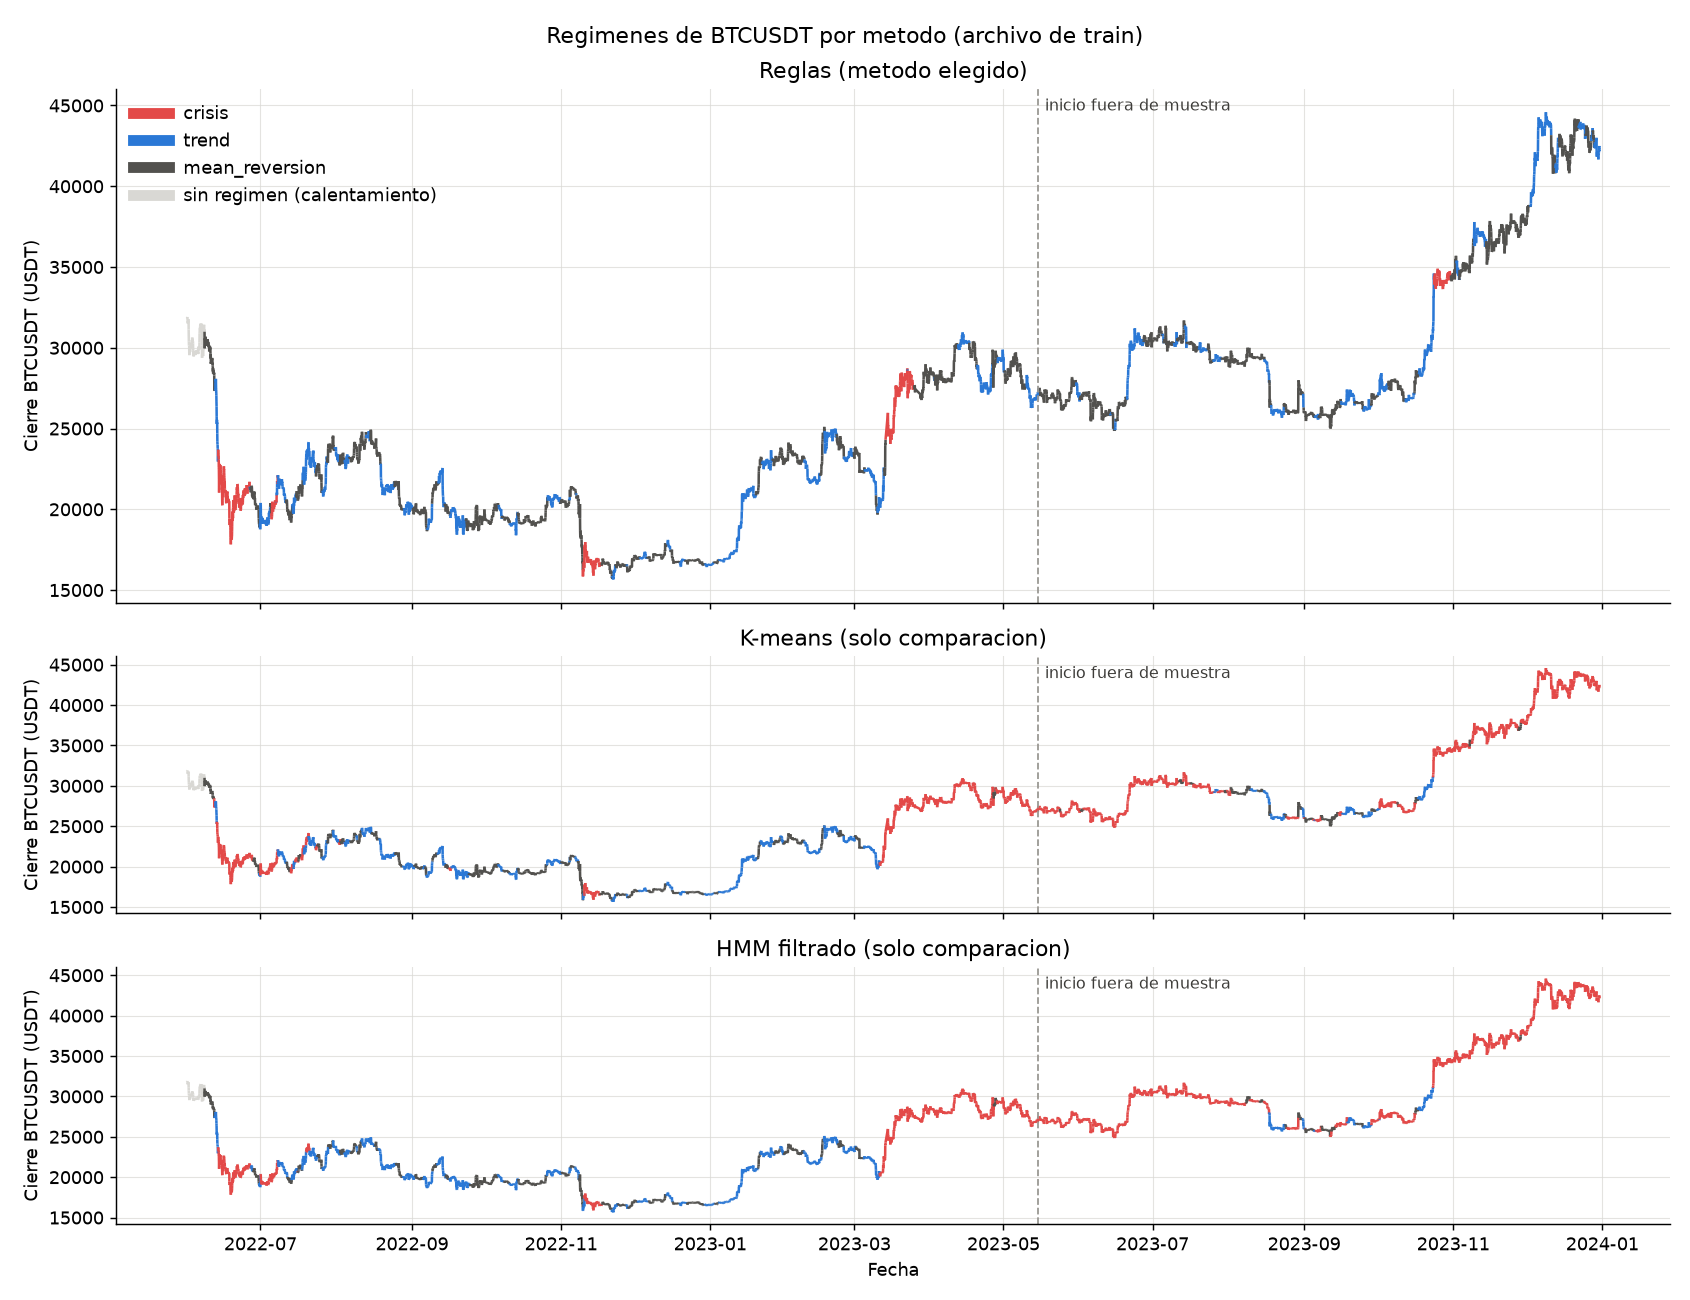

In [21]:
display(Image(filename=str(FIGURES / "regime_timeline.png")))

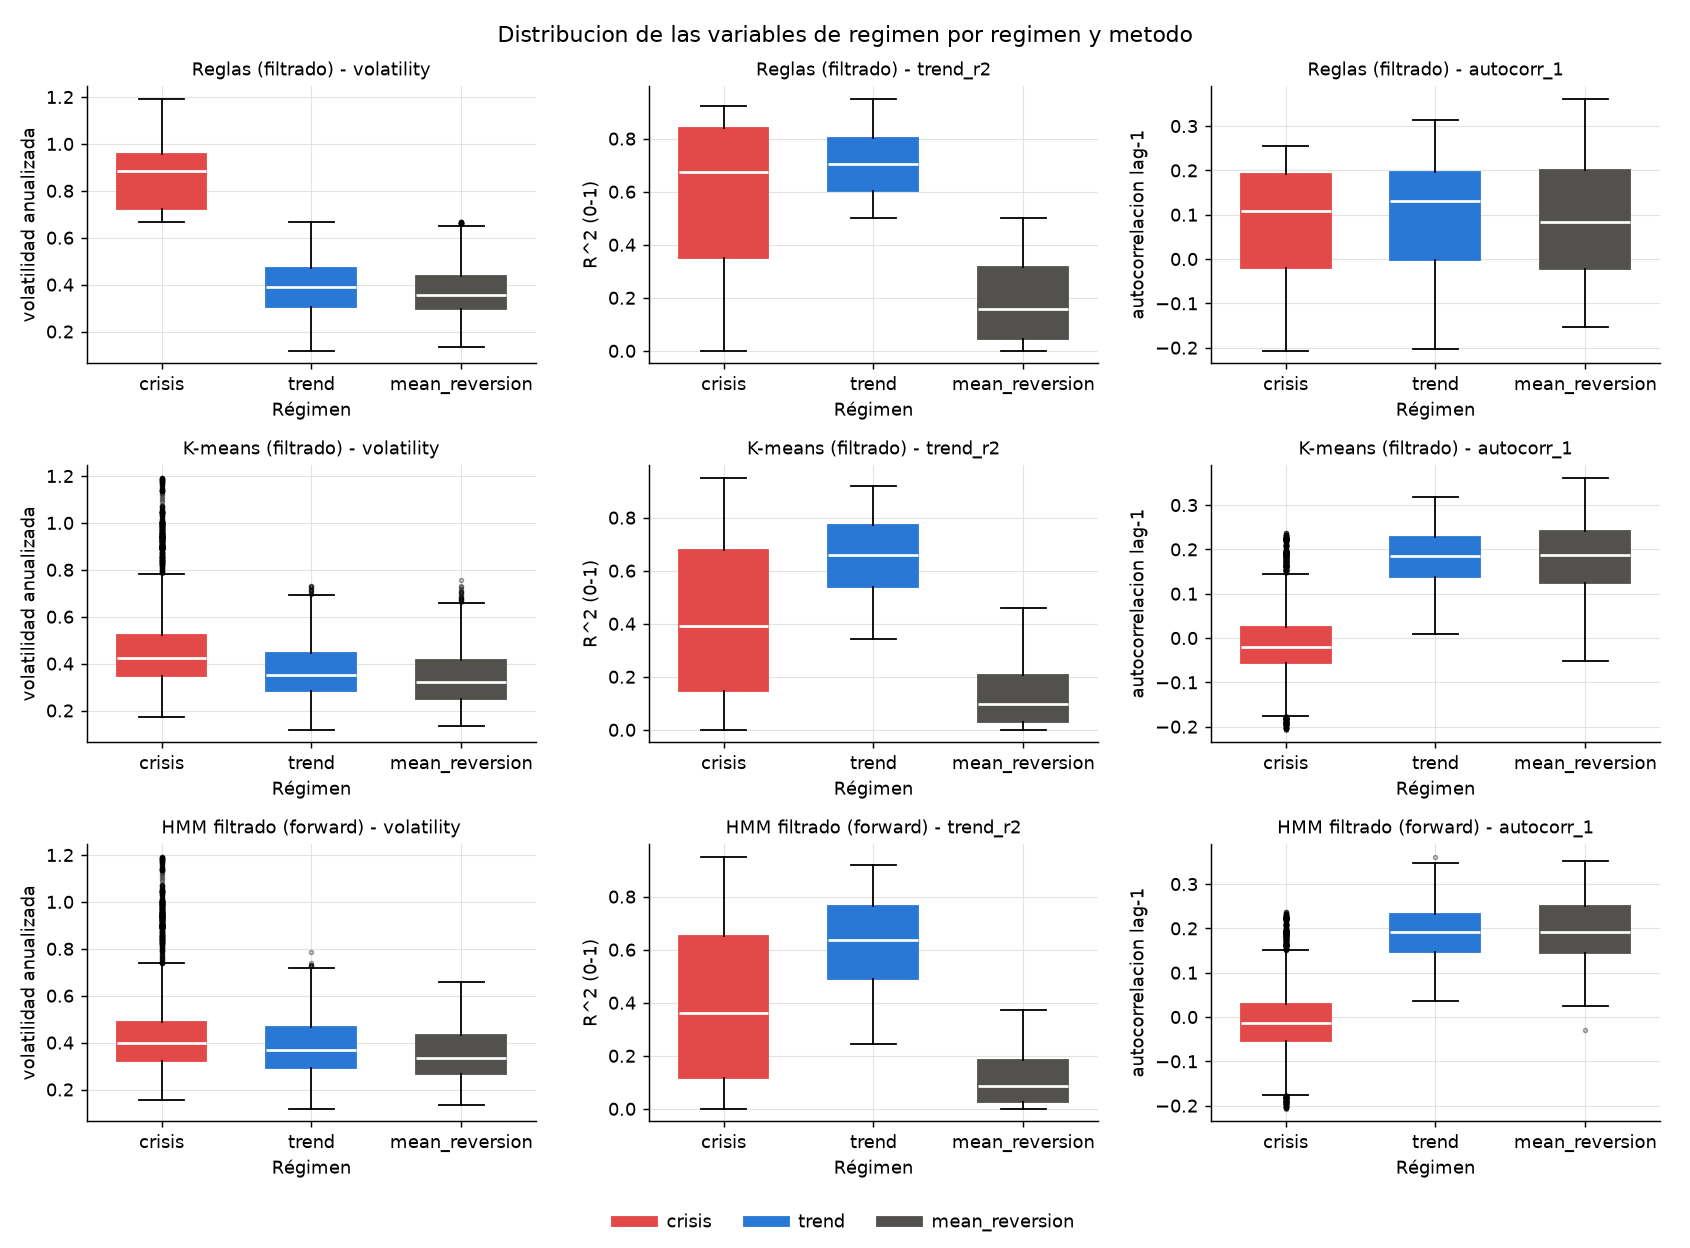

In [22]:
display(Image(filename=str(FIGURES / "regime_features.png")))

### Transiciones y reglas R3 / R5 en la curva OOS

In [23]:
pd.read_csv(TABLES / "transitions.csv", index_col=0).round(3)

,transitions_in_per_month,regime_exits,r5_windows
regime,,,
crisis,0.239,0,59
trend,3.290,1,0
mean_reversion,3.350,0,0
total,6.880,1,59


Se entra a tendencia o a reversión ~3.3 veces por mes y a crisis solo 0.24 veces por mes. R3 (salida
al entrar a crisis) cerró **1** trade; R5 (régimen sin trades suficientes usa los parámetros globales)
se usó en **59 de 73** ventanas, siempre en crisis.

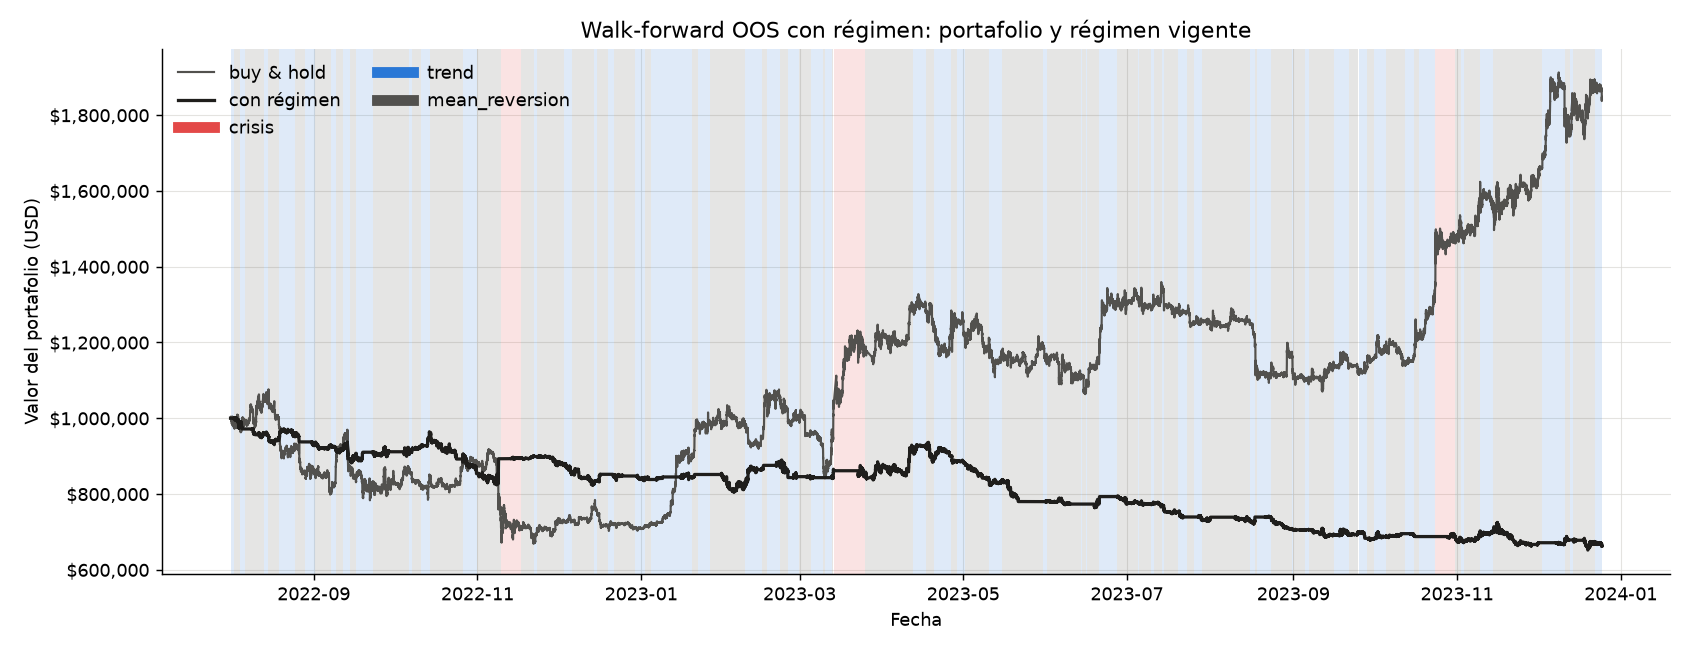

In [24]:
display(Image(filename=str(FIGURES / "portfolio_regimes.png")))

### Estabilidad del régimen: % de tiempo en train contra test

In [25]:
pd.read_csv(TABLES / "regime_shares_train_test.csv", index_col=0).round(1)

,train,test
regime,,
crisis,10.0,22.2
trend,33.0,30.0
mean_reversion,57.0,47.8


En test hay más del doble de crisis (22% contra 10%). Parte puede venir del hueco de 122 días antes de
mayo 2024: la ventana de 1 semana cuenta barras, así que la primera semana de mayo todavía mezcla
barras del 31 de diciembre (ver Limitaciones de los datos).

## 5. Diagnóstico: ¿por qué pierde?

In [26]:
pd.read_csv(TABLES / "diag_exit_reason.csv", index_col=0).round(1)

,exit_reason,n_trades,win_rate,total_pnl
curve,,,,
con_regimen,max_holding,22,68.2,124072.0
con_regimen,opposite_signal,70,15.7,-184817.0
con_regimen,regime_exit,1,100.0,18246.3
con_regimen,stop_loss,54,0.0,-586172.8
con_regimen,take_profit,15,100.0,292793.7
solo_global,max_holding,27,70.4,169308.4
solo_global,opposite_signal,62,16.1,-160582.7
solo_global,stop_loss,35,0.0,-423883.7
solo_global,take_profit,13,100.0,316405.5


In [27]:
pd.read_csv(TABLES / "diag_side.csv", index_col=0).round(1)

,side,n_trades,win_rate,total_pnl
curve,,,,
con_regimen,long,83,25.3,-238980.4
con_regimen,short,79,26.6,-96897.3
solo_global,long,69,29.0,-21695.2
solo_global,short,68,32.4,-77057.2


In [28]:
pd.read_csv(TABLES / "diag_pnl.csv", index_col=0).round(3)

,con_regimen,solo_global
gross_pnl,-146483.235,71842.028
commissions,189394.503,170594.470
slippage,0.000,0.000
borrow_fee,0.000,0.000
net_pnl,-335877.738,-98752.442
avg_win,12457.134,13697.914
avg_loss,7158.978,7095.419
payoff,1.740,1.931
win_rate,25.926,30.657
break_even_win_rate,36.495,34.124


- **Motivo de salida:** con régimen, el stop-loss se lleva −586k en 54 trades y la señal contraria
  −185k en 70 trades con solo 16% de aciertos; take-profit (+293k) y holding máximo (+124k) no alcanzan.
  Muchas posiciones se cierran por señal contraria antes de llegar a su objetivo.
- **Bruto contra comisiones:** solo global gana +72k antes de costos y paga 171k de comisión; con
  régimen ya pierde −146k antes de pagar 189k.
- **Payoff contra break-even:** con payoff de 1.74 (con régimen) y 1.93 (solo global), el win rate
  necesario para no perder es 36.5% y 34.1%; el real es **25.9% y 30.7%**. Las ganancias son más
  grandes que las pérdidas, pero no lo suficiente para pocas operaciones ganadoras.

## 6. Evaluación final en el archivo de test

Se corrió **una sola vez**, con θ_final (mediana de las 73 ventanas), el umbral de régimen ajustado
con todo train y operaciones del 2024-05-02 al 2024-06-03 (el código se subió antes de la corrida).

In [29]:
pd.read_csv(TABLES / "metrics_test.csv", index_col=0).round(3)

,con régimen,solo global,buy & hold
sharpe,3.552,1.889,4.520
sortino,5.278,2.766,6.593
calmar,17.003,6.367,60.771
max_drawdown,-0.043,-0.033,-0.079
win_rate,50.000,33.333,NaN
total_return,0.048,0.017,0.164
n_trades,8.000,6.000,0.000
exposure,0.739,0.616,1.000


Las métricas de arriba están **anualizadas desde un solo mes**, y eso las infla: el Sharpe anual es el
mensual × √12 y el Calmar usa un CAGR que compone un mes bueno doce veces. Abajo, las mismas tres
curvas **sin anualizar**:

In [30]:
test = pd.read_csv(TABLES / "metrics_test.csv", index_col=0)
sin_anualizar = pd.DataFrame({
    "sharpe_mensual": test.loc["sharpe"] / 12 ** 0.5,
    "retorno_del_periodo": test.loc["total_return"],
    "retorno_entre_mdd": test.loc["total_return"] / test.loc["max_drawdown"].abs(),
    "trades": test.loc["n_trades"],
})
sin_anualizar.round(3)

,sharpe_mensual,retorno_del_periodo,retorno_entre_mdd,trades
con régimen,1.025,0.048,1.129,8.0
solo global,0.545,0.017,0.503,6.0
buy & hold,1.305,0.164,2.078,0.0


El Sharpe anual de 3.55 **no es un error**: viene del periodo, que fue muy bueno para BTC (el buy & hold
da 4.5 en el mismo mes). Sin anualizar, la estrategia con régimen gana +4.8% en el mes (Sharpe mensual
~1.0) contra +16.4% del buy & hold.

**Cómo leerlo:** es 1 mes con 8 trades (con régimen) y 6 (solo global). No alcanza para concluir que
hay ventaja, y no contradice el walk-forward, que cubre 17 meses con 162 y 137 trades.

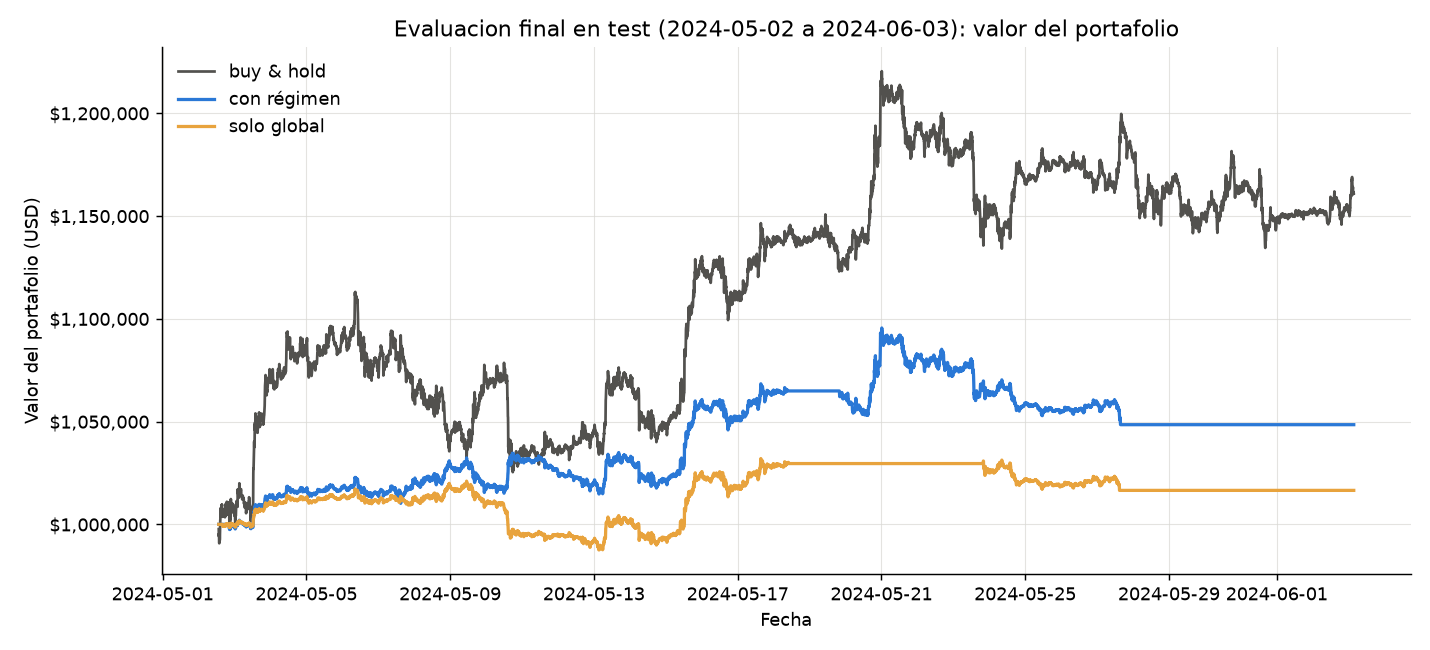

In [31]:
display(Image(filename=str(FIGURES / "portfolio_test.png")))

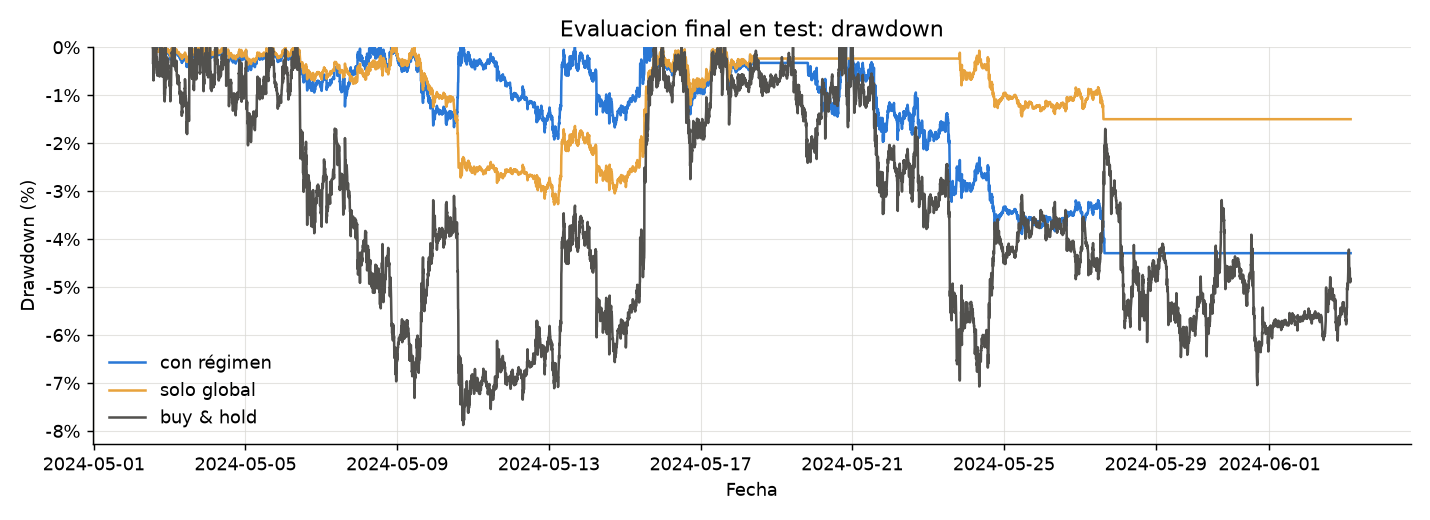

In [32]:
display(Image(filename=str(FIGURES / "drawdown_test.png")))

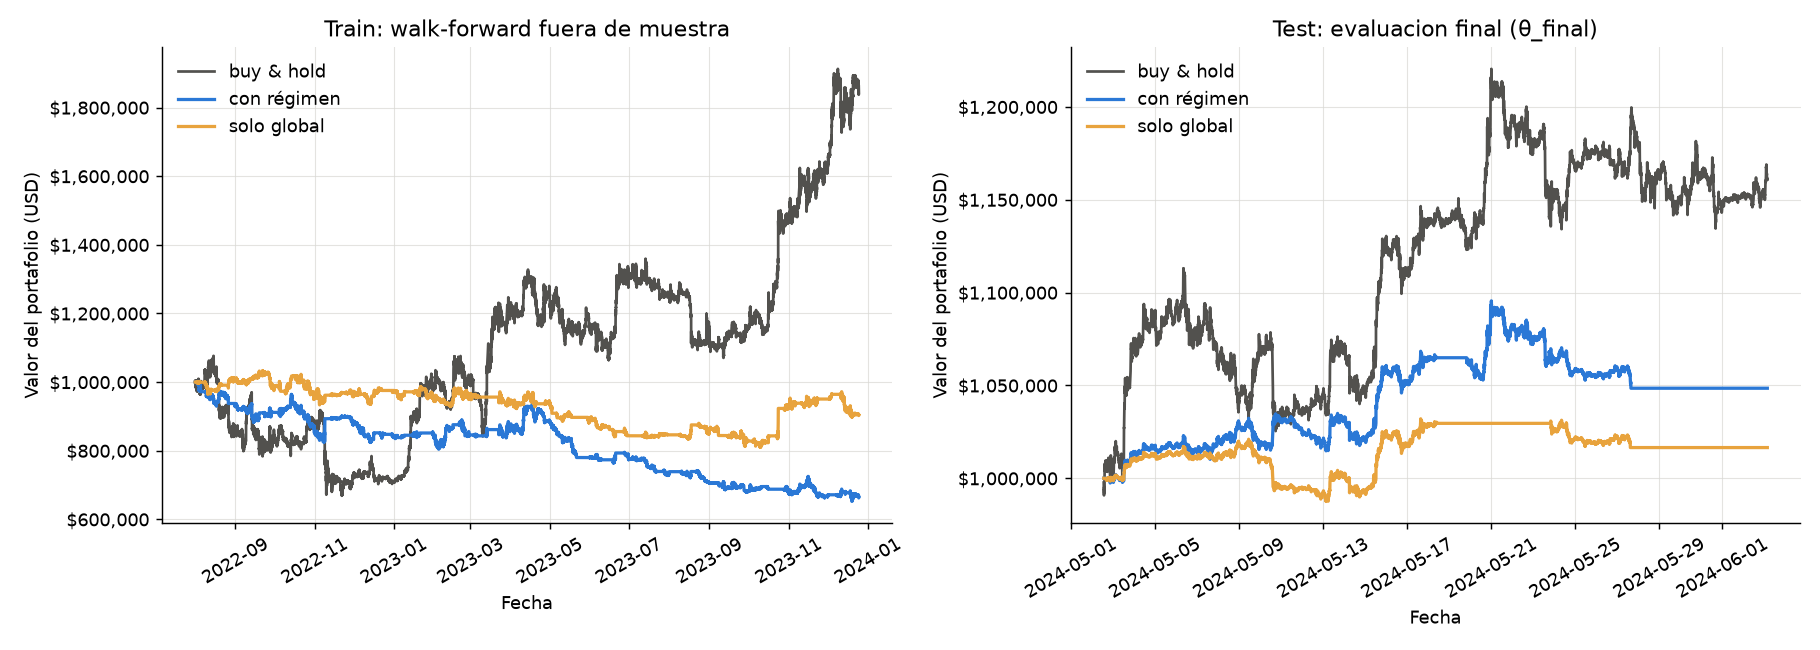

In [33]:
display(Image(filename=str(FIGURES / "portfolio_train_test.png")))

## Limitaciones de los datos

- El volumen falta en el ~48% de las barras del archivo crudo (46% después de la limpieza).
- El archivo de test trae un día suelto (2023-12-31) y luego un hueco de 122 días. Indicadores y
  regímenes cuentan barras, no tiempo: justo después del hueco mezclan diciembre de 2023 con mayo de 2024.
- La primera ventana del walk-forward solo tiene 30 días de calentamiento (los datos empiezan el 2022-06-01).
- Con 1 mes de train hay ~15 señales: los mínimos de trades por estudio (5 global, 3 por régimen) son bajos.

## 7. Conclusión: ¿ventaja real o ajuste a la muestra?

**Ajuste a la muestra.** Con 29,200 configuraciones el optimizador siempre encuentra algo que gana
en cada mes de train (+1.76% por semana en promedio), pero fuera de muestra esa ventaja desaparece:
la curva continua de 17 meses pierde −33.7% con régimen y −9.7% solo global, contra +84.5% del
buy & hold. La sensibilidad muestra un pico, no una meseta; la regla 2 de 3 no mejora a ROC sola; la
capa de régimen empeora el resultado; y aun la versión que gana antes de costos (solo global, +8.7%)
tiene un break-even de 5.6 pb, menos de la mitad de la comisión real. El mes de test positivo (+4.8%,
8 trades, contra +16.4% del buy & hold) no cambia esa conclusión.